# Clasificador de Perros y Gatos
Proyecto de clasificación de imágenes usando TensorFlow y una red CNN. Configurado para ejecución con aceleración de hardware (GPU).

In [17]:
# Verificación de entorno y dependencias
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile


In [18]:
# Configuración de hardware (GPU/CPU)
print("Configurando recursos del sistema...")
import tensorflow as tf

# Configuración fallback para uso de CPU
tf.config.threading.set_inter_op_parallelism_threads(0)
tf.config.threading.set_intra_op_parallelism_threads(0)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU configurada: {gpus[0].name}")
        
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("Precisión mixta activada.")
        
        tf.config.optimizer.set_jit(True)
        print("Compilador XLA activado.")
        
    except RuntimeError as e:
        print(f"Error configurando GPU: {e}")
else:
    print("GPU no detectada. Modo de ejecución definido a CPU.")
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('float32')

Configurando recursos del sistema...
GPU configurada: /physical_device:GPU:0
Precisión mixta activada.
Compilador XLA activado.


In [19]:
# Extracción de datos del dataset
nombre_zip = 'datos.zip'

if not os.path.exists('./mis_datos'):
    print("Extrayendo datos...")
    with zipfile.ZipFile(nombre_zip, 'r') as zip_ref:
        zip_ref.extractall('./mis_datos')
    print("Extracción finalizada.")
else:
    print("Los datos ya se encuentran extraídos en el directorio.")

Los datos ya se encuentran extraídos en el directorio.


In [20]:
# Limpieza de imágenes corruptas en el dataset
print("Verificando integridad de las imágenes...")
import tensorflow as tf

eliminadas = 0
for raiz, carpetas, archivos in os.walk('./mis_datos'):
    for archivo in archivos:
        ruta_completa = os.path.join(raiz, archivo)
        try:
            img_bytes = tf.io.read_file(ruta_completa)
            _ = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        except Exception:
            try:
                os.remove(ruta_completa)
                eliminadas += 1
            except Exception:
                pass

print(f"Limpieza finalizada. Archivos eliminados: {eliminadas}")

Verificando integridad de las imágenes...
Limpieza finalizada. Archivos eliminados: 0


In [21]:
# Preparación de datos (Entrenamiento y Validación)
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE 
LOTE = 32 

train_batches = tf.keras.utils.image_dataset_from_directory(
    './mis_datos/PetImages', validation_split=0.8, subset="training",
    seed=123, image_size=(150, 150), batch_size=LOTE)

val_batches = tf.keras.utils.image_dataset_from_directory(
    './mis_datos/PetImages', validation_split=0.2, subset="validation",
    seed=123, image_size=(150, 150), batch_size=LOTE)

NOMBRES_CLASES = train_batches.class_names
print(f"Clases cargadas: {NOMBRES_CLASES}")

# Optimización del pipeline de datos
train_batches = train_batches.cache().prefetch(buffer_size=AUTOTUNE)
val_batches = val_batches.cache().prefetch(buffer_size=AUTOTUNE)

Found 24991 files belonging to 2 classes.
Using 4999 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.
Clases cargadas: ['Cat', 'Dog']


In [22]:
# Definición de la arquitectura de la red CNN
import tensorflow as tf

modelo = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.7),
    tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
])

modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Arquitectura del modelo compilada.")

Arquitectura del modelo compilada.


In [23]:
# Proceso de entrenamiento
print("Iniciando entrenamiento del modelo...")
historial = modelo.fit(train_batches, validation_data=val_batches, epochs=10)
print("Entrenamiento completado.")

# Guardado de los pesos y arquitectura
modelo.save('modelo_perros_gatos.h5')
print("Archivo de modelo generado: modelo_perros_gatos.h5")

Iniciando entrenamiento del modelo...
Epoch 1/10
157/157 [==============================] - 11s 54ms/step - loss: 0.6971 - accuracy: 0.5677 - val_loss: 0.6580 - val_accuracy: 0.6044
Epoch 2/10
157/157 [==============================] - 8s 50ms/step - loss: 0.6217 - accuracy: 0.6605 - val_loss: 0.5837 - val_accuracy: 0.6857
Epoch 3/10
157/157 [==============================] - 5s 34ms/step - loss: 0.5761 - accuracy: 0.6955 - val_loss: 0.5760 - val_accuracy: 0.7049
Epoch 4/10
157/157 [==============================] - 6s 36ms/step - loss: 0.5473 - accuracy: 0.7271 - val_loss: 0.5326 - val_accuracy: 0.7331
Epoch 5/10
157/157 [==============================] - 6s 36ms/step - loss: 0.4989 - accuracy: 0.7604 - val_loss: 0.5180 - val_accuracy: 0.7437
Epoch 6/10
157/157 [==============================] - 5s 34ms/step - loss: 0.4384 - accuracy: 0.7964 - val_loss: 0.5218 - val_accuracy: 0.7503
Epoch 7/10
157/157 [==============================] - 5s 32ms/step - loss: 0.3933 - accuracy: 0.8242 - 

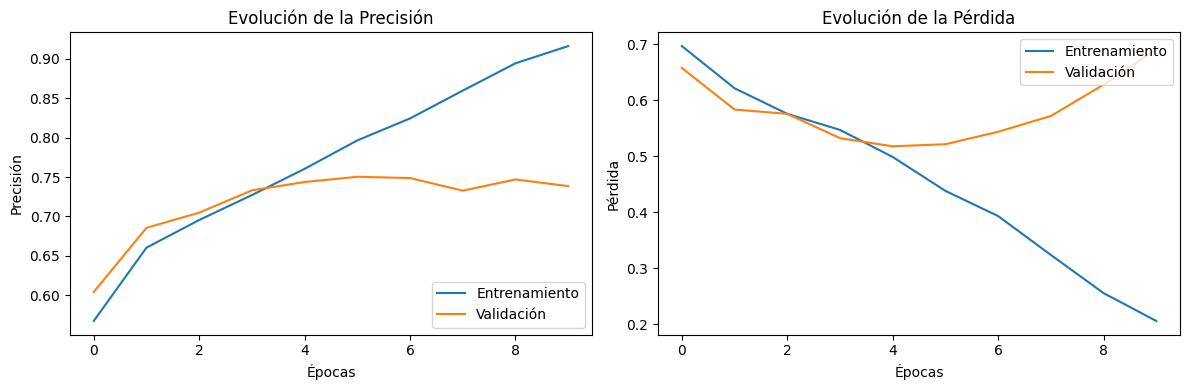

In [24]:
# Visualización de métricas de entrenamiento
plt.figure(figsize=(12, 4))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [25]:
# Evaluación sobre conjunto de validación
loss, accuracy = modelo.evaluate(val_batches)
print(f"Precisión en datos de validación: {accuracy * 100:.2f}%")
print(f"Pérdida calculada: {loss:.4f}")

157/157 [==============================] - 2s 10ms/step - loss: 0.6913 - accuracy: 0.7385
Precisión en datos de validación: 73.85%
Pérdida calculada: 0.6913


1/1 [==============================] - 0s 441ms/step


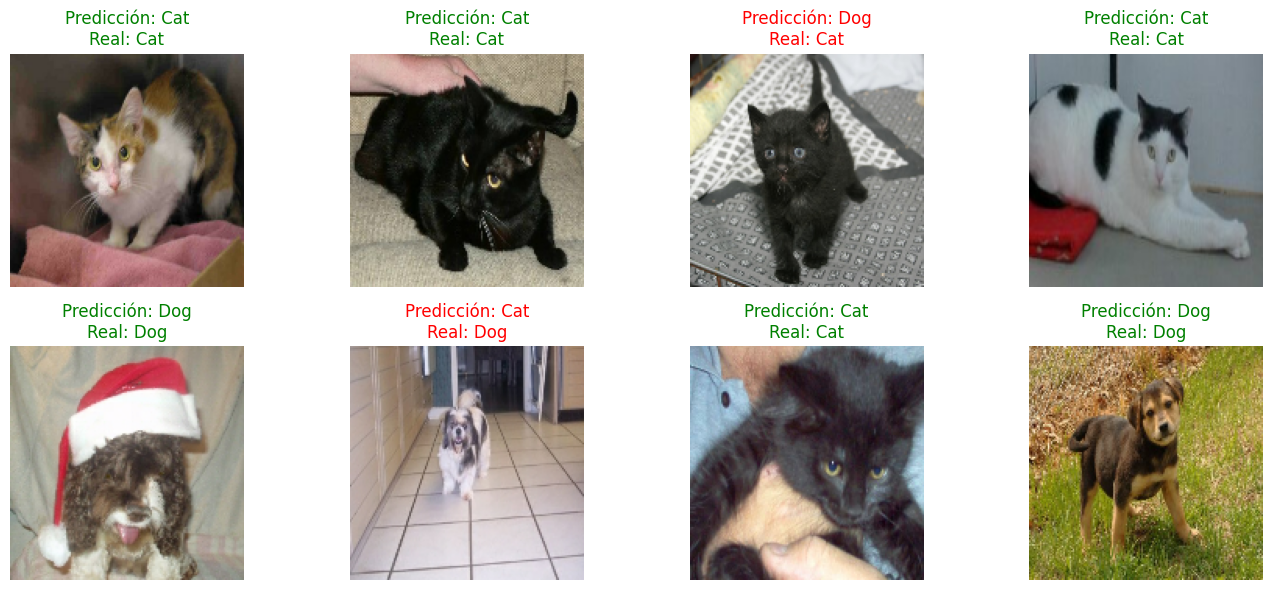

In [26]:
# Demostración visual de carga de modelo y predicción
import tensorflow as tf

modelo_cargado = tf.keras.models.load_model('modelo_perros_gatos.h5')

plt.figure(figsize=(14, 6))

for IMAGENES, ETIQUETAS in val_batches.take(1):
    PREDICCIONES = modelo_cargado.predict(IMAGENES)

    for I in range(8):
        plt.subplot(2, 4, I + 1)
        plt.imshow(IMAGENES[I].numpy().astype("uint8"))

        PRED_LABEL = 1 if PREDICCIONES[I][0] > 0.5 else 0
        REAL_LABEL = int(ETIQUETAS[I].numpy())

        COLOR = 'green' if PRED_LABEL == REAL_LABEL else 'red'
        
        plt.title(f"Predicción: {NOMBRES_CLASES[PRED_LABEL]}\nReal: {NOMBRES_CLASES[REAL_LABEL]}", color=COLOR)
        plt.axis("off")

plt.tight_layout()
plt.show()